In [1]:
from customProphet import *
from prophet import Prophet
import matplotlib.pyplot as plt
import psutil
import time
import pandas as pd
plt.style.use('ggplot')

df = pd.read_csv('peyton_manning.csv')

# Memory Tracker

def get_current_process_memory_usage():
    process = psutil.Process()
    memory_info = process.memory_info()
    return memory_info.rss  # Returning Resident Set Size (physical memory usage)

def run_function_and_get_memory(target_function, num_runs=5, sleep_time=1):
    memory_usages = []

    for _ in range(num_runs):
        # Run the target function
        target_function()
        
        # Wait for a bit to ensure the process memory usage is stable
        time.sleep(sleep_time)
        
        # Get the memory usage of the current process
        memory_usage = get_current_process_memory_usage()
        
        # Add to the list if memory usage is found
        if memory_usage:
            memory_usages.append(memory_usage)
        
    if memory_usages:
        memory_usage = np.array(memory_usages)
        m = memory_usage.mean()
        std = memory_usage.std()
        return m, std
    else:
        return None

/Users/adly/Desktop/customProphet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Gradient sanity check

In [2]:
def loss(model, params):
    k, m, delta, beta = extract_params(params)
    
    A = (model.t_scaled[:, None] > model.change_points) * 1
    gamma = -model.change_points * delta
    g = (k + det_dot(A, delta)) * model.t_scaled + (m + det_dot(A, gamma))

    period = 365.25 / model.scale_period
    x = fourier_components(model.t_scaled, period, 10)
    s = np.dot(x, beta)

    y_pred = g + s
    y_true = model.normalized_y
    r = y_true - y_pred
    
    return np.sum(r**2) / (2 * model.sigma_obs**2) + np.sum(beta**2) / 2*model.sigma**2 \
        + np.sum(np.abs(delta)) / model.tau + k**2 / (2 * model.sigma_k**2) \
        + m**2 / (2 * model.sigma_m**2)
        
def gradient(model, params):
    k, m, delta, beta = extract_params(params)
    
    A = (model.t_scaled[:, None] > model.change_points) * 1
    gamma = -model.change_points * delta
    g = (k + np.dot(A, delta)) * model.t_scaled + (m + np.dot(A, gamma))

    period = 365.25 / model.scale_period
    x = fourier_components(model.t_scaled, period, 10)
    s = np.dot(x, beta)

    y_pred = g + s
    y_true = model.normalized_y
    r = y_true - y_pred
    
    dk = np.array([-np.sum(r * model.t_scaled) / model.sigma_obs**2 + k / model.sigma_k**2])
    dm = np.array([-np.sum(r) / model.sigma_obs**2 + m / model.sigma_m**2])
    ddelta = -np.sum(r[:, None] * (model.t_scaled[:, None] - model.change_points) * A, axis=0) / model.sigma_obs**2 + np.sign(delta) / model.tau
    dbeta = -np.dot(r, x) / model.sigma_obs**2 + beta / model.sigma**2
    
    return np.concatenate([dk, dm, ddelta, dbeta])    

def numerical_gradient(loss, model, params, epsilon=1e-6):
    num_grad = np.zeros_like(params)
    for i in range(len(params)):
        params_perturbed = params.copy()
        params_perturbed[i] += epsilon
        loss_plus_epsilon = loss(model, params_perturbed)
        
        params_perturbed[i] -= 2 * epsilon
        loss_minus_epsilon = loss(model, params_perturbed)
        
        num_grad[i] = (loss_plus_epsilon - loss_minus_epsilon) / (2 * epsilon)
    
    return num_grad


## instantiate & initialize a model
model = CustomProphet()
model.y = df['y'].values
if df['ds'].dtype != 'datetime64[ns]':
    model.ds = pd.to_datetime(df['ds'])
else:
    model.ds = df['ds']

model.t_scaled = np.array((model.ds - model.ds.min()) / (model.ds.max() - model.ds.min()))
model.T = df.shape[0]

model.scale_period = (model.ds.max() - model.ds.min()).days
model._normalize_y()
model._generate_change_points()

params = np.ones((47,))
# Calculate numerical gradient
num_grad = numerical_gradient(loss, model, params)

# Calculate analytical gradient
anl_grad = gradient(model, params)

are_close = np.allclose(anl_grad, num_grad)

# If you need to inspect the differences
differences = anl_grad - num_grad

# Print results
print("Are the gradients approximately equal?", are_close)
print("Differences:", differences)


Are the gradients approximately equal? False
Differences: [-8.10515136e-04  2.29005050e-03 -4.40318603e-03 -1.04682427e-03
  5.37560321e-04 -1.15432218e-03  3.88207287e-03 -4.11876570e-03
 -5.28838765e-03 -1.86859630e-03 -2.23895023e-03 -1.68482121e-03
  1.22132525e-03 -3.77054326e-03  3.49593908e-03 -6.16766140e-03
 -5.28740743e-03 -4.92857234e-03 -8.41357978e-04 -3.08276876e-03
 -2.32292525e-03 -1.38106360e-03 -1.21344591e-03 -7.53457181e-03
 -7.93993112e-03  3.16488848e-03 -5.24618872e-03 -9.99882358e+01
 -9.99860957e+01 -9.99884259e+01 -9.99904840e+01 -9.99921730e+01
 -9.99986904e+01 -9.99936735e+01 -9.99899916e+01 -9.99923117e+01
 -9.99932545e+01 -9.99927313e+01 -9.99888226e+01 -9.99870643e+01
 -9.99878721e+01 -9.99910172e+01 -9.99904962e+01 -9.99953721e+01
 -9.99940785e+01 -9.99898594e+01 -9.99917814e+01]


$\displaystyle g(t_i) = (k + a(t_i)\delta)t_i + (m + a(t_i)\gamma)\\
\frac{\partial g(t_i)}{\partial \delta} = t_ia(t_i) - \text{changepoints}\ a(t_i)\\
s(t_i) = \sum a_n \cos(\frac{2\pi t_i n}{P}) + b_n \sin(\frac{2\pi t_i n}{P}) = X(t_i) \beta\\
\frac{\partial s(t_i)}{\partial \beta} = X(t_i) \\
\mathcal{L}(k, m, \delta, \beta) = \frac{1}{2\sigma_{obs}^{2}} \sum_{i=1}^{T} \left[y_i - (g(t_i) + s(t_i))\right]^2 + \frac{1}{\tau}\sum |\delta_i| + \frac{1}{2\sigma^2}\sum \beta_i^2 + \frac{k^2}{2\sigma_k^2} + \frac{m^2}{2\sigma_m^2} \\ - \frac{1}{\sigma_{obs}^2} \sum [r_i t_i a(t_i)] + \frac{1}{\tau} \text{sgn} \ \delta$

In [3]:
model = CustomProphet()
model.fit_cpp(df)

Iteration 1: fx = 730761, xnorm = 12.0688, gnorm = 1.25277e+06, step = 2.82366e-08
Iteration 2: fx = 482571, xnorm = 12.0235, gnorm = 483706, step = 11.2085
Iteration 3: fx = 398108, xnorm = 11.9636, gnorm = 674949, step = 2.62309
Iteration 4: fx = 217133, xnorm = 11.8462, gnorm = 192821, step = 3.24304
Iteration 5: fx = 212690, xnorm = 11.8362, gnorm = 102494, step = 0.325401
Iteration 6: fx = 130576, xnorm = 11.2679, gnorm = 559373, step = 83.8971
Iteration 7: fx = 82754.5, xnorm = 11.0638, gnorm = 65502.8, step = 0.601821
Iteration 8: fx = 81148.9, xnorm = 11.0491, gnorm = 119509, step = 2.48271
Iteration 9: fx = 79389.5, xnorm = 11.0307, gnorm = 324259, step = 1.42524
Iteration 10: fx = 27451.5, xnorm = 10.6884, gnorm = 222185, step = 33.5205
Iteration 11: fx = 22206.3, xnorm = 10.6776, gnorm = 23724, step = 0.319489
Iteration 12: fx = 22137.2, xnorm = 10.677, gnorm = 9555.8, step = 1.16872
Iteration 13: fx = 22098, xnorm = 10.675, gnorm = 14002.4, step = 4.07654
Iteration 14: fx =

-1

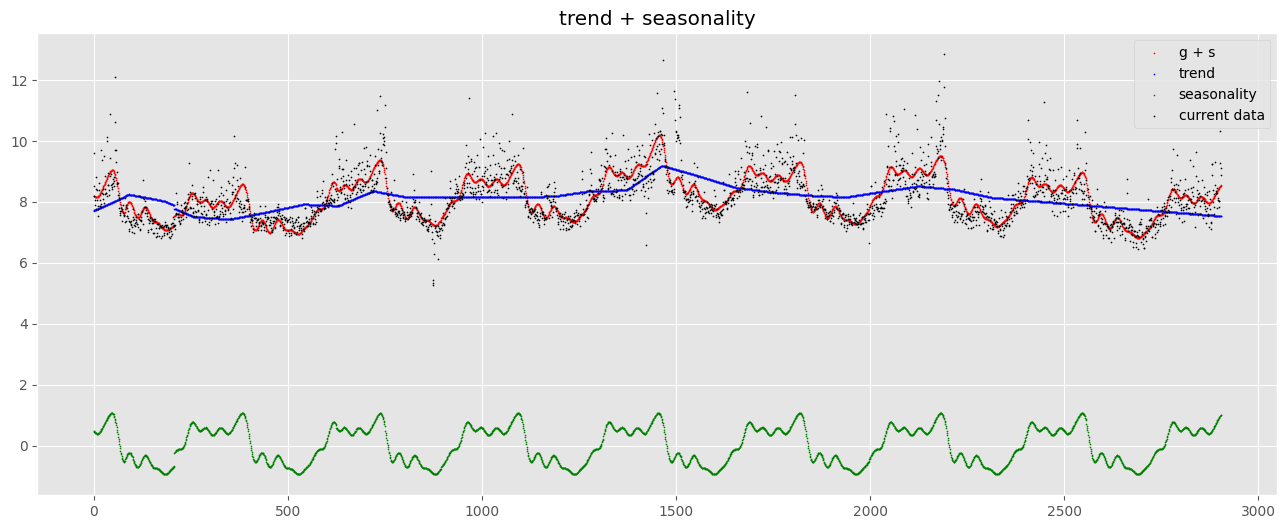

In [4]:
opt_params = model.get_parameters()
k, m, delta, beta = extract_params(opt_params)

# trend component
A = (model.t_scaled[:, None] > model.change_points) * 1
gamma = -model.change_points * delta
g = ((k + np.dot(A, delta)) * model.t_scaled + (m + np.dot(A, gamma))) * model.y_absmax

x = fourier_components(model.t_scaled, 365.25 / model.scale_period, 10)
s = det_dot(x, beta) * model.y_absmax

plt.figure(figsize=(16, 6))
plt.title('trend + seasonality')
plt.scatter(np.arange(df.shape[0]), g+s, s=0.5, label='g + s', color='red')
plt.scatter(np.arange(df.shape[0]), g, s=0.5, label='trend', color='blue')
plt.scatter(np.arange(df.shape[0]), s, s=0.5, label='seasonality', color='green')
plt.scatter(np.arange(df.shape[0]), model.y, s=0.5, label='current data', color='black')
plt.legend()
plt.show()

In [4]:
future = model.make_future_dataframe(periods=365)
pred = model.predict(future)
pred

,ds,trend,trend_lower,trend_upper,yhat_lower,yhat_upper,seasonality,yhat
0,2007-12-10,7.423240,7.423240,7.423240,7.916446,7.916446,0.493206,7.916446
1,2007-12-11,7.430936,7.423839,7.423839,7.903483,7.903483,0.479643,7.910579
2,2007-12-12,7.438631,7.424438,7.424438,7.890963,7.890963,0.466525,7.905156
3,2007-12-13,7.446327,7.425037,7.425037,7.879286,7.879286,0.454249,7.900575
4,2007-12-14,7.454022,7.425636,7.425712,7.868822,7.868897,0.443186,7.897208
...,...,...,...,...,...,...,...,...
3265,2017-01-15,7.075830,-58.962496,92.486641,-57.960860,93.488277,1.001636,8.077466
3266,2017-01-16,7.074663,-58.960189,92.482796,-57.933083,93.509901,1.027105,8.101768
3267,2017-01-17,7.073495,-58.957881,92.478952,-57.906243,93.530589,1.051638,8.125133
3268,2017-01-18,7.072328,-58.955574,92.475107,-57.880612,93.550069,1.074962,8.147290


/var/folders/59/g78zms8d1qdfyxr2yzf9bzr40000gn/T/ipykernel_49176/910158147.py:42: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  date = future['ds'].dt.to_pydatetime()


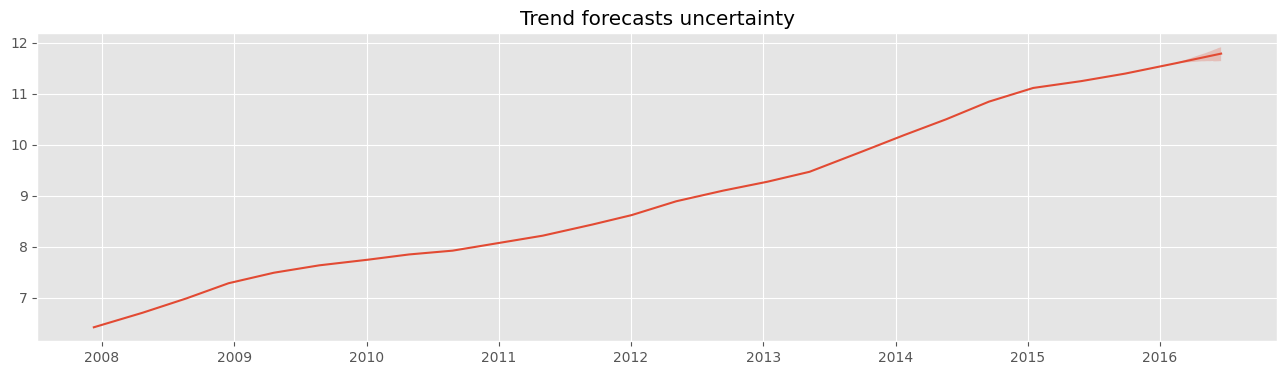

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Ensure 'ds' column is in datetime format
df['ds'] = pd.to_datetime(df['ds'])

# Parameters
n_changepoints = 25
n_samples = 1000
days = 150
history_points = df.shape[0]
probability_changepoint = n_changepoints / history_points

# Create future dataframe
future = pd.DataFrame({'ds': pd.date_range(df['ds'].min(), df['ds'].max() + pd.Timedelta(days, 'D'), df.shape[0] + days)})
future['t'] = (future['ds'] - df['ds'].min()) / (df['ds'].max() - df['ds'].min())

# Simulate parameters (replace these with your actual values if available)
k = 0.5  # Example value
m = 0.5  # Example value
delta = np.random.normal(0, 0.1, n_changepoints)  # Example values
lambda_ = 0.1  # Example value
s = np.linspace(0, 1, n_changepoints)  # Example changepoints

trend_forecast = []

for n in range(n_samples):
    new_changepoints = future['t'][future['t'] > 1].values
    sample = np.random.random(new_changepoints.shape)
    new_changepoints = new_changepoints[sample <= probability_changepoint]
    new_delta = np.r_[delta, stats.laplace(0, lambda_).rvs(new_changepoints.shape[0])]
    new_s = np.r_[s, new_changepoints]
    new_A = (future['t'].values[:, None] > new_s) * 1  # Convert to numpy array before indexing

    trend_forecast.append(((k + np.dot(new_A, new_delta)) * future['t'] + (m + np.dot(new_A, (-new_s * new_delta)))) * df['y'].max())

trend_forecast = np.array(trend_forecast)

# Plotting
date = future['ds'].dt.to_pydatetime()
plt.figure(figsize=(16, 4))
plt.title('Trend forecasts uncertainty')
plt.plot(date, trend_forecast.mean(0))
quant = np.quantile(trend_forecast, [0.025, 0.975], axis=0)
plt.fill_between(date, quant[0, :], quant[1, :], alpha=0.25)
plt.show()

In [17]:
model = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
model.fit(df)
future = model.make_future_dataframe(periods=365)
pred = model.predict(future)
pred

16:12:35 - cmdstanpy - INFO - Chain [1] start processing
16:12:35 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2007-12-10,8.030540,7.750634,9.124156,8.030540,8.030540,0.455321,0.455321,0.455321,0.455321,0.455321,0.455321,0.0,0.0,0.0,8.485861
1,2007-12-11,8.029035,7.843853,9.121596,8.029035,8.029035,0.438311,0.438311,0.438311,0.438311,0.438311,0.438311,0.0,0.0,0.0,8.467345
2,2007-12-12,8.027529,7.724129,9.108644,8.027529,8.027529,0.422169,0.422169,0.422169,0.422169,0.422169,0.422169,0.0,0.0,0.0,8.449698
3,2007-12-13,8.026024,7.786409,9.104360,8.026024,8.026024,0.407335,0.407335,0.407335,0.407335,0.407335,0.407335,0.0,0.0,0.0,8.433359
4,2007-12-14,8.024518,7.743021,9.075234,8.024518,8.024518,0.394211,0.394211,0.394211,0.394211,0.394211,0.394211,0.0,0.0,0.0,8.418730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3265,2017-01-15,7.207589,7.397448,8.892160,6.893055,7.553497,0.972163,0.972163,0.972163,0.972163,0.972163,0.972163,0.0,0.0,0.0,8.179752
3266,2017-01-16,7.206592,7.412369,8.899618,6.890801,7.553150,0.994659,0.994659,0.994659,0.994659,0.994659,0.994659,0.0,0.0,0.0,8.201250
3267,2017-01-17,7.205594,7.464396,8.979785,6.888940,7.552804,1.016178,1.016178,1.016178,1.016178,1.016178,1.016178,0.0,0.0,0.0,8.221771
3268,2017-01-18,7.204596,7.485072,9.050001,6.887297,7.552458,1.036507,1.036507,1.036507,1.036507,1.036507,1.036507,0.0,0.0,0.0,8.241103


## Finite Differences Peyton Manning

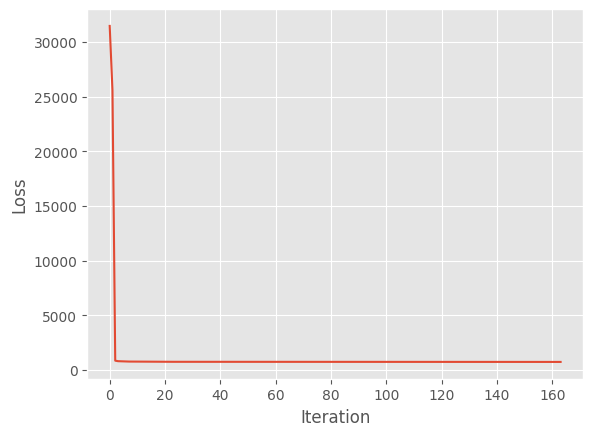

In [6]:
model = CustomProphet()
model.fit(df)

# Plot the loss over iterations
plt.plot(model.loss_over_iterations)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

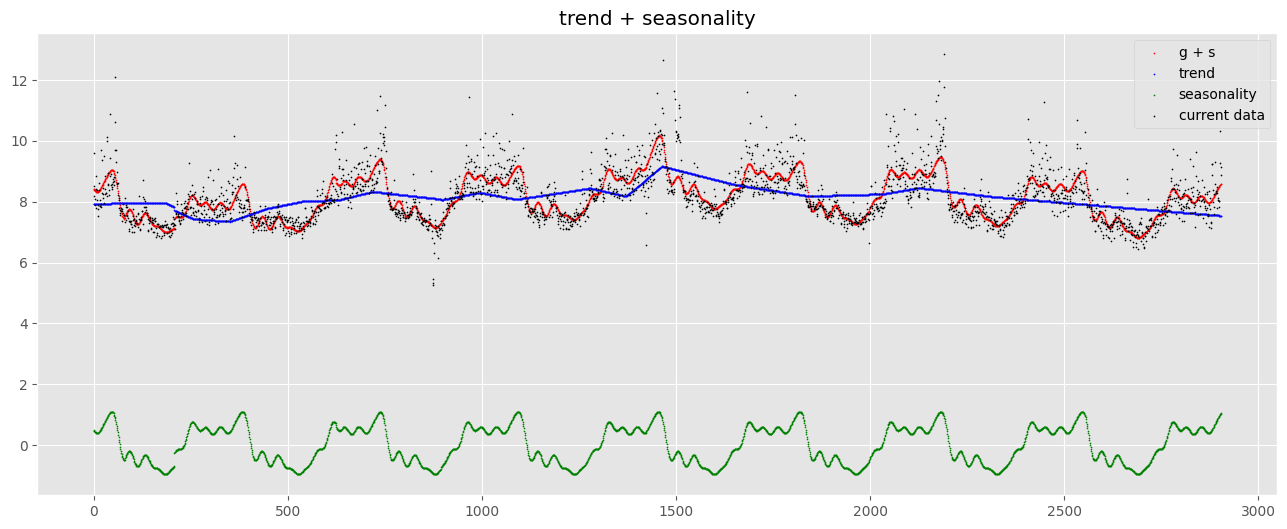

In [17]:
opt_params = model.get_parameters()
k, m, delta, beta = extract_params(opt_params)

# trend component
A = (model.t_scaled[:, None] > model.change_points) * 1
gamma = -model.change_points * delta
g = ((k + np.dot(A, delta)) * model.t_scaled + (m + np.dot(A, gamma))) * model.y_absmax
#g = ((k + det_dot(A, delta)) * model.t_scaled + (m + det_dot(A, gamma))) * model.y_absmax

x = fourier_components(model.t_scaled, 365.25 / model.scale_period, 10)
s = det_dot(x, beta) * model.y_absmax

plt.figure(figsize=(16, 6))
plt.title('trend + seasonality')
plt.scatter(np.arange(df.shape[0]), g+s, s=0.5, label='g + s', color='red')
plt.scatter(np.arange(df.shape[0]), g, s=0.5, label='trend', color='blue')
plt.scatter(np.arange(df.shape[0]), s, s=0.5, label='seasonality', color='green')
plt.scatter(np.arange(df.shape[0]), model.y, s=0.5, label='current data', color='black')
plt.legend()
plt.show()

In [8]:
model.opt, delta

(  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
   success: True
    status: 0
       fun: 731.0407330844004
         x: [-1.772e-01  6.155e-01 ...  3.719e-04 -5.898e-03]
       nit: 164
       jac: [-8.764e+00 -3.709e+01 ... -6.615e+00  1.291e+01]
      nfev: 11568
      njev: 241
  hess_inv: <47x47 LbfgsInvHessProduct with dtype=float64>,
 array([-1.68662096e-04,  1.67579603e-03,  1.47323706e-01,  2.81057188e-01,
        -6.12278489e-10,  2.03984273e-04, -3.71772420e-02, -9.77737614e-02,
        -1.65389638e-05, -8.37735521e-05,  1.30390664e-03,  5.93133353e-02,
         5.43600034e-02,  6.27352304e-05, -2.16932913e-05, -2.23185022e-01,
        -1.93572385e-01,  2.99068025e-04, -4.79561546e-04,  6.06610645e-02,
        -1.08125242e-03, -4.71484806e-04, -1.83109929e-03, -4.75121076e-02,
        -3.30384842e-02]))

## Analytic Gradient Peyton Manning

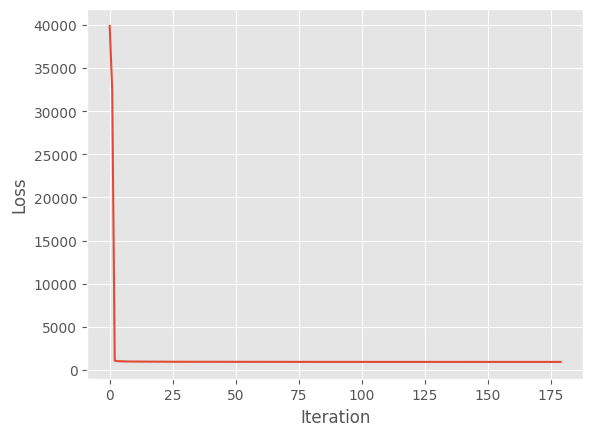

In [5]:
model = CustomProphet()
model.fit(df, analytic=True)

# Plot the loss over iterations
plt.plot(model.loss_over_iterations)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

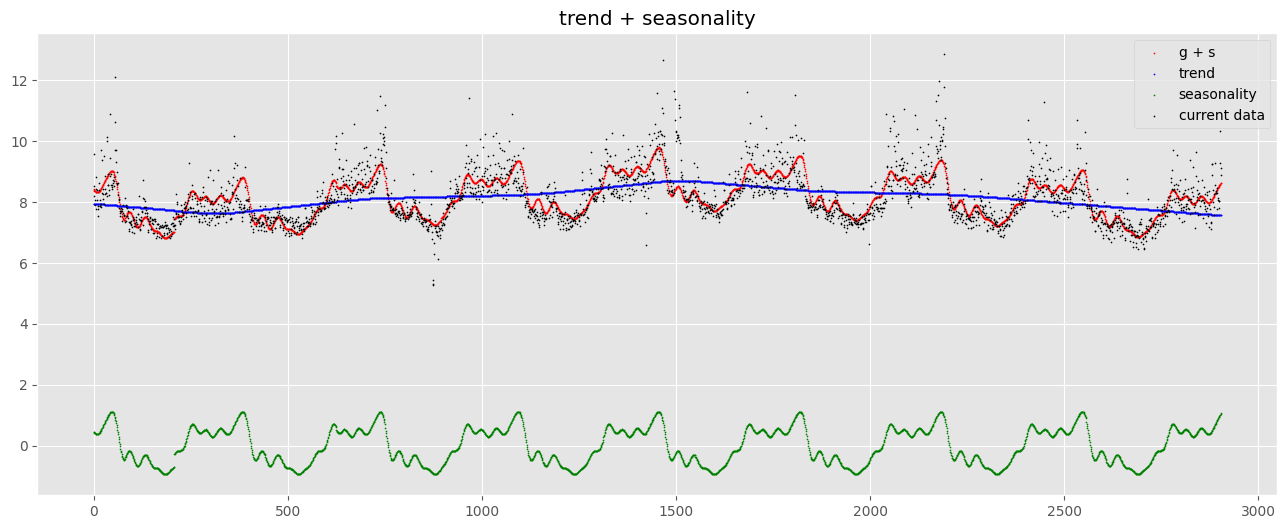

In [6]:
opt_params = model.get_parameters()
k, m, delta, beta = extract_params(opt_params)

# trend component
A = (model.t_scaled[:, None] > model.change_points) * 1
gamma = -model.change_points * delta
g = ((k + det_dot(A, delta)) * model.t_scaled + (m + det_dot(A, gamma))) * model.y_absmax

x = fourier_components(model.t_scaled, 365.25 / model.scale_period, 10)
s = det_dot(x, beta) * model.y_absmax

plt.figure(figsize=(16, 6))
plt.title('trend + seasonality')
plt.scatter(np.arange(df.shape[0]), g+s, s=0.5, label='g + s', color='red')
plt.scatter(np.arange(df.shape[0]), g, s=0.5, label='trend', color='blue')
plt.scatter(np.arange(df.shape[0]), s, s=0.5, label='seasonality', color='green')
plt.scatter(np.arange(df.shape[0]), model.y, s=0.5, label='current data', color='black')
plt.legend()
plt.show()

In [11]:
model.opt, delta

(  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
   success: True
    status: 0
       fun: 58.20529105764432
         x: [ 1.194e-01  5.978e-01 ...  5.998e-04 -5.881e-03]
       nit: 126
       jac: [ 9.797e+00 -2.412e+00 ...  3.182e+00 -1.303e+00]
      nfev: 213
      njev: 213
  hess_inv: <47x47 LbfgsInvHessProduct with dtype=float64>,
 array([ 4.85091961e-05,  4.11996164e-05, -1.26044431e-05,  4.94868750e-06,
        -7.19247456e-06, -5.45953893e-06,  4.05056934e-05, -1.76872375e-07,
        -9.94757471e-05, -2.09331999e-05, -1.01471068e-04, -2.67948898e-06,
        -1.12178046e-04, -9.44489221e-03, -2.98161347e-02, -5.03040106e-02,
        -5.40357385e-02, -4.57722753e-02, -3.22770388e-02, -1.66370667e-02,
        -6.40562866e-03,  2.62344552e-10, -1.98271524e-04, -6.14341674e-05,
        -1.04080878e-06]))

## Objective + Gradient Combined Peyton Manning

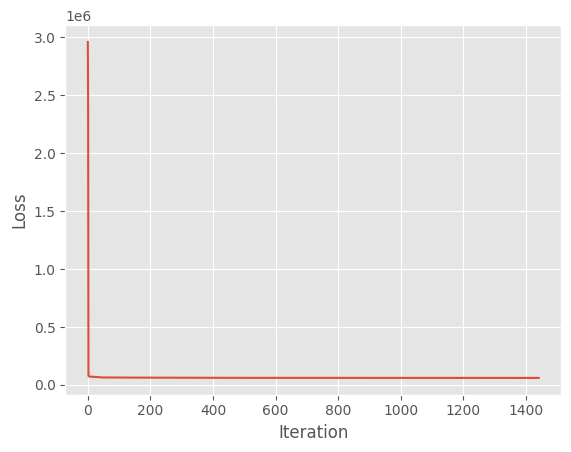

In [18]:
model = CustomProphet()
model.fit(df, use_combined=True)

# Plot the loss over iterations
plt.plot(model.loss_over_iterations)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

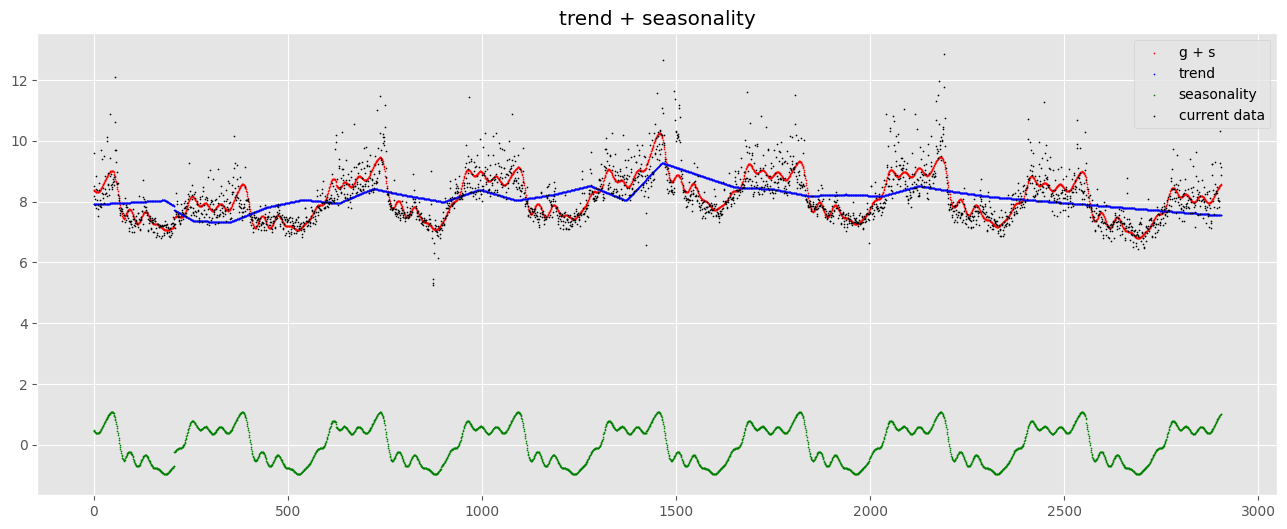

In [19]:
opt_params = model.get_parameters()
k, m, delta, beta = extract_params(opt_params)

# trend component
A = (model.t_scaled[:, None] > model.change_points) * 1
gamma = -model.change_points * delta
g = ((k + np.dot(A, delta)) * model.t_scaled + (m + np.dot(A, gamma))) * model.y_absmax
#g = ((k + det_dot(A, delta)) * model.t_scaled + (m + det_dot(A, gamma))) * model.y_absmax

x = fourier_components(model.t_scaled, 365.25 / model.scale_period, 10)
s = det_dot(x, beta) * model.y_absmax

plt.figure(figsize=(16, 6))
plt.title('trend + seasonality')
plt.scatter(np.arange(df.shape[0]), g+s, s=0.5, label='g + s', color='red')
plt.scatter(np.arange(df.shape[0]), g, s=0.5, label='trend', color='blue')
plt.scatter(np.arange(df.shape[0]), s, s=0.5, label='seasonality', color='green')
plt.scatter(np.arange(df.shape[0]), model.y, s=0.5, label='current data', color='black')
plt.legend()
plt.show()

In [20]:
model.opt, delta

(  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
   success: True
    status: 0
       fun: 59864.47430346858
         x: [ 1.267e-01  6.162e-01 ...  5.154e-04 -5.845e-03]
       nit: 1442
       jac: [-1.717e+02 -1.862e+02 ... -4.931e+01  1.259e+02]
      nfev: 1599
      njev: 1599
  hess_inv: <47x47 LbfgsInvHessProduct with dtype=float64>,
 array([ 5.85548423e-02, -1.84009302e+00,  1.55485451e+00,  1.29076418e+00,
        -5.74975354e-01, -9.21491914e-01,  1.49196605e+00, -1.77124632e+00,
         8.77873073e-02,  1.50927782e+00, -1.88004680e+00,  1.32424138e+00,
         2.54631221e-01, -1.89009825e+00,  4.20216477e+00, -4.00733794e+00,
        -2.88211310e-09,  8.49446968e-01, -4.14787152e-01,  6.63350025e-01,
        -2.51589033e-01,  9.61881005e-01, -1.30543301e+00,  7.80740151e-02,
         1.66177108e-01]))

## Fitting Time

In [ ]:
%%timeit -r 10 -n 10

# Finite differences
model = CustomProphet()
model.fit(df)

In [ ]:
%%timeit -r 10 -n 10

# Analytic
model = CustomProphet()
model.fit(df, analytic=True)

In [2]:
%%timeit -r 10 -n 10

# Combined
model = CustomProphet()
model.fit(df, use_combined=True)

The slowest run took 4.14 times longer than the fastest. This could mean that an intermediate result is being cached.
1.43 s ± 531 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


In [3]:
%%timeit -r 10 -n 10

# Prophet
model = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
model.fit(df)

14:55:50 - cmdstanpy - INFO - Chain [1] start processing
14:55:50 - cmdstanpy - INFO - Chain [1] done processing
14:55:50 - cmdstanpy - INFO - Chain [1] start processing
14:55:51 - cmdstanpy - INFO - Chain [1] done processing
14:55:51 - cmdstanpy - INFO - Chain [1] start processing
14:55:51 - cmdstanpy - INFO - Chain [1] done processing
14:55:51 - cmdstanpy - INFO - Chain [1] start processing
14:55:51 - cmdstanpy - INFO - Chain [1] done processing
14:55:51 - cmdstanpy - INFO - Chain [1] start processing
14:55:52 - cmdstanpy - INFO - Chain [1] done processing
14:55:52 - cmdstanpy - INFO - Chain [1] start processing
14:55:52 - cmdstanpy - INFO - Chain [1] done processing
14:55:52 - cmdstanpy - INFO - Chain [1] start processing
14:55:52 - cmdstanpy - INFO - Chain [1] done processing
14:55:52 - cmdstanpy - INFO - Chain [1] start processing
14:55:52 - cmdstanpy - INFO - Chain [1] done processing
14:55:53 - cmdstanpy - INFO - Chain [1] start processing
14:55:53 - cmdstanpy - INFO - Chain [1]

326 ms ± 3.96 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


In [2]:
%%timeit -r 20 -n 10

# Custom Prophet using C++ backend
model = CustomProphet()
model.fit_cpp(df)

Iteration 1: fx = 118101, xnorm = 8.89871, gnorm = 136035, step = 7.77641e-07
Iteration 2: fx = 40903.2, xnorm = 8.8139, gnorm = 30762.1, step = 10.7336
Iteration 3: fx = 32775.7, xnorm = 8.66235, gnorm = 40855.1, step = 2.16412
Iteration 4: fx = 10978.3, xnorm = 8.27102, gnorm = 19073.2, step = 4.2017
Iteration 5: fx = 9848.76, xnorm = 8.24634, gnorm = 6330.11, step = 0.289355
Iteration 6: fx = 7822.18, xnorm = 8.00155, gnorm = 23230.7, step = 18.085
Iteration 7: fx = 1548.89, xnorm = 7.58182, gnorm = 4011.17, step = 3.32771
Iteration 8: fx = 1530.37, xnorm = 7.58119, gnorm = 4278.66, step = 0.10232
Iteration 9: fx = 1513.45, xnorm = 7.58004, gnorm = 598.778, step = 1.70637
Iteration 10: fx = 1506.88, xnorm = 7.57129, gnorm = 1451.49, step = 20.0908
Iteration 11: fx = 1336.17, xnorm = 7.34539, gnorm = 4679.12, step = 29.4641
Iteration 12: fx = 1211.57, xnorm = 7.20498, gnorm = 1998.96, step = 0.79298
Iteration 13: fx = 1195.52, xnorm = 7.18696, gnorm = 957.918, step = 0.834022
Iterati

## Memory Tracking

In [ ]:
# Finite differences
def prophetFit():
    model = CustomProphet()
    model.fit(df)

average_memory_usage, std = run_function_and_get_memory(prophetFit, num_runs=30, sleep_time=1)
if average_memory_usage:
    print(f"Average memory usage over 30 runs: {average_memory_usage / 1024**2} MB +/- {std / 1024**2} MB")
else:
    print("Failed to measure memory usage.")

In [ ]:
# Analytic
def prophetFit():
    model = CustomProphet()
    model.fit(df, analytic=True)
    
average_memory_usage, std = run_function_and_get_memory(prophetFit, num_runs=100, sleep_time=1)
if average_memory_usage:
    print(f"Average memory usage over 100 runs: {average_memory_usage / 1024**2} MB +/- {std / 1024**2} MB")
else:
    print("Failed to measure memory usage.")

In [ ]:
# Combined
def prophetFit():
    model = CustomProphet()
    model.fit(df, use_combined=True)
    
average_memory_usage, std = run_function_and_get_memory(prophetFit, num_runs=100, sleep_time=1)
if average_memory_usage:
    print(f"Average memory usage over 100 runs: {average_memory_usage / 1024**2} MB +/- {std / 1024**2} MB")
else:
    print("Failed to measure memory usage.")

In [10]:
# Prophet
def prophetFit():
    model = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
    model.fit(df)

# Example usage:
average_memory_usage, std = run_function_and_get_memory(prophetFit, num_runs=100, sleep_time=1)
if average_memory_usage:
    print(f"Average memory usage over 30 runs: {average_memory_usage / 1024**2} MB +/- {std / 1024**2} MB")
else:
    print("Failed to measure memory usage.")

17:05:49 - cmdstanpy - INFO - Chain [1] start processing
17:05:49 - cmdstanpy - INFO - Chain [1] done processing
17:05:50 - cmdstanpy - INFO - Chain [1] start processing
17:05:51 - cmdstanpy - INFO - Chain [1] done processing
17:05:52 - cmdstanpy - INFO - Chain [1] start processing
17:05:52 - cmdstanpy - INFO - Chain [1] done processing
17:05:53 - cmdstanpy - INFO - Chain [1] start processing
17:05:54 - cmdstanpy - INFO - Chain [1] done processing
17:05:55 - cmdstanpy - INFO - Chain [1] start processing
17:05:55 - cmdstanpy - INFO - Chain [1] done processing
17:05:56 - cmdstanpy - INFO - Chain [1] start processing
17:05:56 - cmdstanpy - INFO - Chain [1] done processing
17:05:57 - cmdstanpy - INFO - Chain [1] start processing
17:05:58 - cmdstanpy - INFO - Chain [1] done processing
17:05:59 - cmdstanpy - INFO - Chain [1] start processing
17:05:59 - cmdstanpy - INFO - Chain [1] done processing
17:06:00 - cmdstanpy - INFO - Chain [1] start processing
17:06:00 - cmdstanpy - INFO - Chain [1]

Average memory usage over 30 runs: 88.911875 MB +/- 41.54058771062044 MB


In [19]:
# Prophet
def prophet_cppFit():
    model = CustomProphet()
    model.fit_cpp(df)

# Example usage:
average_memory_usage, std = run_function_and_get_memory(prophet_cppFit, num_runs=100, sleep_time=1)
if average_memory_usage:
    print(f"Average memory usage over 30 runs: {average_memory_usage / 1024**2} MB +/- {std / 1024**2} MB")
else:
    print("Failed to measure memory usage.")

Iteration 1: fx = 534251, xnorm = 9.44472, gnorm = 446772, step = 3.25737e-07
Iteration 2: fx = 192826, xnorm = 9.09151, gnorm = 127626, step = 10.531
Iteration 3: fx = 143164, xnorm = 8.83463, gnorm = 145742, step = 1.92794
Iteration 4: fx = 10740, xnorm = 8.29302, gnorm = 61781.2, step = 4.71202
Iteration 5: fx = 6338.08, xnorm = 8.28681, gnorm = 7269.36, step = 0.218103
Iteration 6: fx = 6220.31, xnorm = 8.28109, gnorm = 7030.37, step = 1.95922
Iteration 7: fx = 3511.37, xnorm = 8.08201, gnorm = 11688.8, step = 47.5951
Iteration 8: fx = 3408.22, xnorm = 8.07615, gnorm = 13662.6, step = 0.0517803
Iteration 9: fx = 3359.3, xnorm = 8.07366, gnorm = 1327.26, step = 0.820782
Iteration 10: fx = 3338.71, xnorm = 8.06233, gnorm = 4239.65, step = 45.0648
Iteration 11: fx = 1948.91, xnorm = 7.35531, gnorm = 12689, step = 73.7584
Iteration 12: fx = 1766.48, xnorm = 7.31305, gnorm = 4799.97, step = 0.166848
Iteration 13: fx = 1755.25, xnorm = 7.30925, gnorm = 1478.9, step = 1.32987
Iteration 14